# Exercise 10.2

## 201910936 김연수

In [26]:
import thinkdsp
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, irfft, rfftfreq
from scipy.signal import resample_poly
from math import gcd

%matplotlib inline

ir_file  = 'data/ir.wav'
dry_file = 'data/dry.wav'

ir_wave  = thinkdsp.read_wave(ir_file)
dry_wave = thinkdsp.read_wave(dry_file)

# Manage Identical Sample Rate Manually

if ir_wave.framerate == dry_wave.framerate:
    print(f'Sample rate Identical: {ir_wave.framerate} Hz')
    
else:
    print(f'Sample rate Different : IR ... {ir_wave.framerate}Hz, While Dry ... {dry_wave.framerate}Hz')
    print(f'Converting IR Sample Rate to ... {dry_wave.framerate}Hz')

    g    = gcd(ir_wave.framerate, dry_wave.framerate)
    up   = dry_wave.framerate // g
    down = ir_wave.framerate  // g

    ir_resampled = resample_poly(ir_wave.ys, up, down)
    ir_wave      = thinkdsp.Wave(ys=ir_resampled, framerate=dry_wave.framerate)

    print(f'✅ Complete! IR New Sample Rate ... {ir_wave.framerate} Hz')

Sample rate Different : IR ... 96000Hz, While Dry ... 48000Hz
Converting IR Sample Rate to ... 48000Hz
✅ Complete! IR New Sample Rate ... 48000 Hz


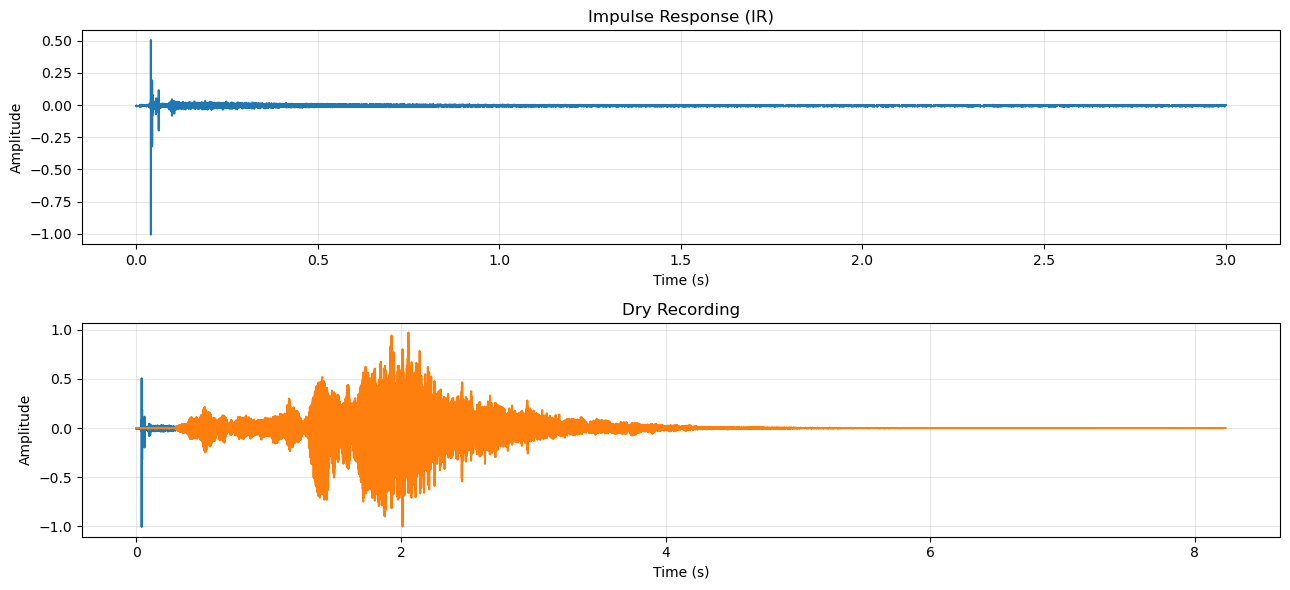

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))

# Impulse Response
ir_wave.plot()
plt.sca(axes[0])
ir_wave.plot()
axes[0].set_title('Impulse Response (IR)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# Dry Recording
plt.sca(axes[1])
dry_wave.plot()
axes[1].set_title('Dry Recording')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# IR 청취
print('Impulse Response')
ir_wave.make_audio()

# Dry recording 청취
print('Dry Recording')
dry_wave.make_audio()

Impulse Response
Dry Recording


In [29]:
# method 1 : convolution

dry_ys = dry_wave.ys.astype(float)
ir_ys  = ir_wave.ys.astype(float)

# if Stereo IR, convert to mono
if ir_ys.ndim == 2:
    ir_ys = ir_ys.mean(axis=1)
    print('IR: Stereo → Mono')

# Normalization
dry_ys = dry_ys / np.max(np.abs(dry_ys))
ir_ys  = ir_ys  / np.max(np.abs(ir_ys))

# Convolution Process
conv_ys = np.convolve(dry_ys, ir_ys)

# Result Normalization
conv_ys = conv_ys / np.max(np.abs(conv_ys))

# Create Think DSP Wave
conv_wave = thinkdsp.Wave(ys=conv_ys, framerate=dry_wave.framerate)

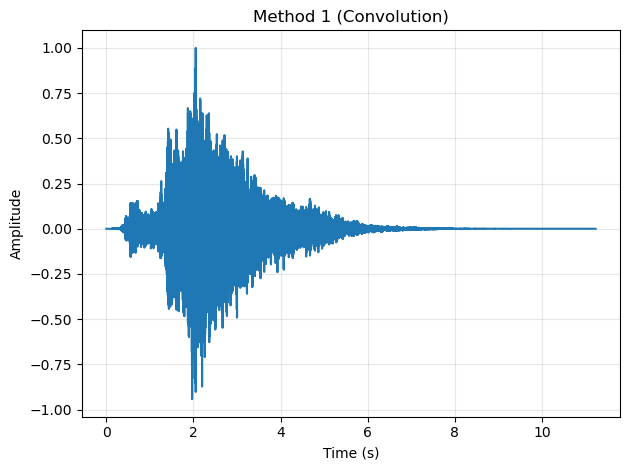

Convolution Result:


In [30]:
# Method 1 Visualization

conv_wave.plot()
plt.title('Method 1 (Convolution)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sound Result
print('Convolution Result:')
conv_wave.make_audio()

In [31]:
# Method 2 : DFT

# Zero-padding
N = len(dry_ys) + len(ir_ys) - 1

# FFT
X = rfft(dry_ys, n=N)   # dry
H = rfft(ir_ys,  n=N)   # ir
Y = X * H

fft_ys = irfft(Y, n=N)[:N]

# Normalization
fft_ys = fft_ys / np.max(np.abs(fft_ys))

# Create Think DSP Wave
fft_wave = thinkdsp.Wave(ys=fft_ys, framerate=dry_wave.framerate)

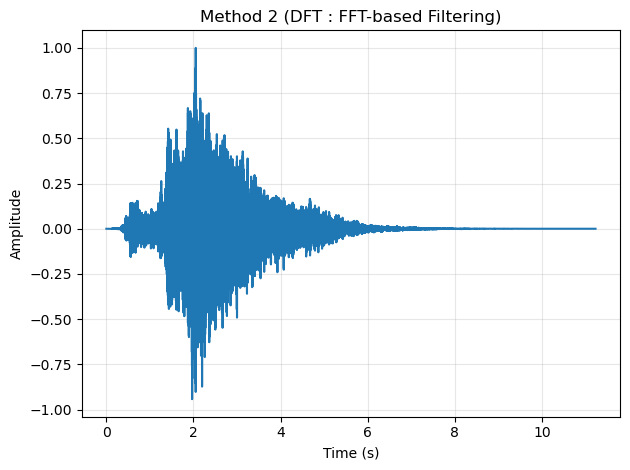

In [32]:
# Method 2 Result Visualization

fft_wave.plot()
plt.title('Method 2 (DFT : FFT-based Filtering)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sound Result
fft_wave.make_audio()